# PROYECTO 1 DATA ANALYTICS II

# Importamos librerías necesarias 

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import math
from rich import print

# Cargamos Csv ratings

In [11]:
# Cargar archivo ratings
ratings = pd.read_csv("ratings.csv")

# División por usuario: 80% entrenamiento, 20% prueba
def split_train_test(ratings, test_size=0.2):
    train_list, test_list = [], []

    for user_id, group in ratings.groupby('userId'):
        if len(group) < 2:
            continue
        train, test = train_test_split(group, test_size=test_size, random_state=42)
        train_list.append(train)
        test_list.append(test)

    return pd.concat(train_list), pd.concat(test_list)

train_ratings, test_ratings = split_train_test(ratings)


**En este fragmento de código, hemos cargado el archivo csv "ratings", necesario para poder el filtrado. Este conjunto lo dividiremos en dos subconjuntos internos; uno de entrenamiento(train), que será el 80% del total y el 20% restante será el correspodniente al subconjunto de prueba(test). Asegurando un registro para cada uno de os inidividuos registrados en el csv. Al tener un registro de prueba y entrenamiento por cada individuo nos asegura una coherencia para corroborar las predicciones.**

# Cargamos Csv movies 

In [13]:
movies = pd.read_csv("movies.csv")
movies["genres"] = movies["genres"].str.split("|")

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(movies["genres"])

movie_ids = movies["movieId"].values
movie_id_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

# Similitud coseno entre películas
cosine_sim = cosine_similarity(genre_matrix)


**En este fragmento de código, cargo el segundo csv necesario que será "movies", en el cual cada fila es una película. Extraemos los géneros de cada película, y los agrupamos en listas. Empleamos MultiLabelBinarizer para convertir las listas de etiquetas múltiples en matriz de 1 y 0, llamado también "One-Hot enconding". Tomará valor 1 cuando la pelócula tenga ese género y 0 cuando no. Crea un índice con los números identificadores de cada película, de tal forma que nos permita acceder mas fácilmente a estas. Después, calculamos la similitud entre las películas, usando la matriz de cosimilitud, tomando 1 cuando haya géneros en común y 0 cuando no.**

# Matriz de Similitud 

In [15]:
print(cosine_similarity(genre_matrix))

[[1.         0.77459667 0.31622777 ... 0.         0.31622777 0.4472136 ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.         0.         0.70710678]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.31622777 0.         0.         ... 0.         1.         0.        ]
 [0.4472136  0.         0.70710678 ... 0.         0.         1.        ]]

In [17]:
print(movies.tail(10))

movieId                                              title  \
9732   193565                          Gintama: The Movie (2010)   
9733   193567  anohana: The Flower We Saw That Day - The Movi...   
9734   193571                                Silver Spoon (2014)   
9735   193573            Love Live! The School Idol Movie (2015)   
9736   193579           Jon Stewart Has Left the Building (2015)   
9737   193581          Black Butler: Book of the Atlantic (2017)   
9738   193583                       No Game No Life: Zero (2017)   
9739   193585                                       Flint (2017)   
9740   193587                Bungo Stray Dogs: Dead Apple (2018)   
9741   193609                Andrew Dice Clay: Dice Rules (1991)   

                                    genres  
9732   [Action, Animation, Comedy, Sci-Fi]  
9733                    [Animation, Drama]  
9734                       [Comedy, Drama]  
9735                           [Animation]  
9736                         [Documentary]  
9737  [Action, Animation, Comedy, Fantasy]  
9738          [Animation, Comedy, Fantasy]  
9739                               [Drama]  
9740                   [Action, Animation]  
9741                              [Comedy]

In [19]:
mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(movies["genres"])

In [21]:
cosine_sim = cosine_similarity(genres_encoded, genres_encoded)
print(cosine_sim)

[[1.         0.77459667 0.31622777 ... 0.         0.31622777 0.4472136 ]
 [0.77459667 1.         0.         ... 0.         0.         0.        ]
 [0.31622777 0.         1.         ... 0.         0.         0.70710678]
 ...
 [0.         0.         0.         ... 1.         0.         0.        ]
 [0.31622777 0.         0.         ... 0.         1.         0.        ]
 [0.4472136  0.         0.70710678 ... 0.         0.         1.        ]]

# Sistema de recomendación en base a título de película

In [23]:
def get_recommendations(title, cosine_sim=cosine_sim):
    idx = movies[movies["title"].str.contains(title, case=False)].index[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:11]
    movie_indices = [i[0] for i in sim_scores]
    return movies[["title","genres"]].iloc[movie_indices]

**En este fragmento comenzamos definiendo una función "get_recommendations", donde tomará como parámetros el título de la película y la matriz de cosimilitud, calculada anteriormente. Busca el título de la película en el dataframe "movies". Extrae el vector de similitudes de la película seleccionada con todas las demás. Ordena los pares (índice, puntuación) de mayor a menor según la similitud. Se salta el primero (sim_scores[0]) porque sería la película consigo misma (similitud 1).
Se queda con los 10 siguientes (las 10 películas más similares). Así las películas más parecidas aparecen primero. Extrae solo los índices de las películas más parecidas. devuelve un dataframe con los títulos y puntuaciones recomendadas.**

In [25]:
print(get_recommendations("Silver Spoon"))

title           genres
67                             Big Bully (1996)  [Comedy, Drama]
74              Antonia's Line (Antonia) (1995)  [Comedy, Drama]
85                In the Bleak Midwinter (1995)  [Comedy, Drama]
94   Nobody Loves Me (Keiner liebt mich) (1994)  [Comedy, Drama]
129                     Blue in the Face (1995)  [Comedy, Drama]
143                              Jeffrey (1995)  [Comedy, Drama]
150                 Love & Human Remains (1993)  [Comedy, Drama]
164                                Smoke (1995)  [Comedy, Drama]
173                      Unstrung Heroes (1995)  [Comedy, Drama]
186                     Boys on the Side (1995)  [Comedy, Drama]

In [44]:
print(get_recommendations("Smoke"))

title           genres
67                             Big Bully (1996)  [Comedy, Drama]
74              Antonia's Line (Antonia) (1995)  [Comedy, Drama]
85                In the Bleak Midwinter (1995)  [Comedy, Drama]
94   Nobody Loves Me (Keiner liebt mich) (1994)  [Comedy, Drama]
129                     Blue in the Face (1995)  [Comedy, Drama]
143                              Jeffrey (1995)  [Comedy, Drama]
150                 Love & Human Remains (1993)  [Comedy, Drama]
164                                Smoke (1995)  [Comedy, Drama]
173                      Unstrung Heroes (1995)  [Comedy, Drama]
186                     Boys on the Side (1995)  [Comedy, Drama]

**Podemos observar el ejemplo con las películas "Silver Spoon" y "Smoke"**

# Predicción de calificación

In [27]:
def predict_content(user_id, movie_id, k):
    if movie_id not in movie_id_to_index:
        return np.nan

    movie_idx = movie_id_to_index[movie_id]
    user_data = train_ratings[train_ratings["userId"] == user_id]

    sims, ratings_ = [], []

    for _, row in user_data.iterrows():
        rated_movie = row["movieId"]
        if rated_movie not in movie_id_to_index:
            continue
        idx = movie_id_to_index[rated_movie]
        sim = cosine_sim[movie_idx][idx]
        sims.append(sim)
        ratings_.append(row["rating"])

    if not sims:
        return np.nan

    sims, ratings_ = np.array(sims), np.array(ratings_)
    top_k_idx = sims.argsort()[-k:]
    top_k_sims, top_k_ratings = sims[top_k_idx], ratings_[top_k_idx]

    return np.dot(top_k_sims, top_k_ratings) / np.sum(top_k_sims) if np.sum(top_k_sims) > 0 else np.mean(top_k_ratings)


**La función predict_content predice qué calificación (rating) le daría un usuario a una película basándose en las películas que ya ha visto y en la similitud de géneros entre películas. Primero, verifica si la película existe en el sistema; si no, devuelve NaN. Luego, obtiene todas las películas que el usuario ya calificó en el conjunto de entrenamiento, y calcula cuánto se parece cada una de esas películas a la nueva película usando la matriz de similitud coseno (cosine_sim). Solo guarda las similitudes y calificaciones de las películas que también existen en el sistema. Si no hay ninguna película comparable, devuelve NaN. Después convierte las similitudes y calificaciones en arrays de numpy y selecciona las k películas más parecidas a la nueva, ordenándolas por similitud. Finalmente, predice el rating calculando un promedio ponderado de las calificaciones, donde las películas más similares tienen más peso; si la suma de las similitudes es cero (es decir, si no hay nada muy parecido), simplemente hace un promedio normal de las calificaciones de esas k películas. Así, se logra estimar de manera inteligente qué tan probable es que al usuario le guste la nueva película basándose en su historial de gustos y en el parecido de los contenidos.**

In [29]:
print(predict_content(23, 45, 5))


3.9881553646890877

# Predicción calificación a películas según calificaciones previas 

In [31]:
def predict_user_score(user_id,movie_title,cosine_sim=cosine_sim):
    movie_idx = movies[movies["title"].str.contains(movie_title, case=False)].index[0]
    user_ratings = ratings[ratings["userId"]==user_id]
    if user_ratings.empty:
        raise ValueError("User not found")
    user_movie_indices = user_ratings["movieId"].apply(lambda x: movies[movies["movieId"]==x].index[0])
    sim_scores = cosine_sim[movie_idx][user_movie_indices]
    user_scores = user_ratings["rating"].values
    if np.sum(sim_scores)==0:
        return user_scores.mean()
    predicted_score = np.dot(sim_scores,user_scores)/np.sum(sim_scores)
    return predicted_score

**La función predict_user_score estima la calificación que un usuario daría a una película específica, basándose en las calificaciones que ya ha hecho a otras películas y en la similitud entre películas. Primero, busca el índice de la película objetivo (por su título) en el DataFrame movies. Luego, recoge todas las calificaciones que ese usuario ha registrado (ratings), y si no encuentra ninguna calificación, lanza un error indicando que el usuario no existe. Después, convierte las movieId que el usuario calificó en sus respectivos índices dentro del DataFrame movies, para poder comparar usando la matriz de similitud coseno (cosine_sim). Obtiene la similitud de cada película calificada con la nueva película, y también extrae las puntuaciones que el usuario dio a esas películas. Si todas las similitudes son cero (es decir, no hay películas similares), la función devuelve simplemente el promedio de las calificaciones del usuario. Si hay similitud significativa, calcula una predicción mediante un promedio ponderado, donde las películas más parecidas tienen más influencia sobre la predicción final. Así, esta función combina información del comportamiento previo del usuario y de la similitud de contenido entre películas para hacer una predicción personalizada del gusto del usuario.**

In [35]:
print(predict_user_score(34, "Silver Spoon"))

3.2071948211287595

# Evaluación del RMSE 

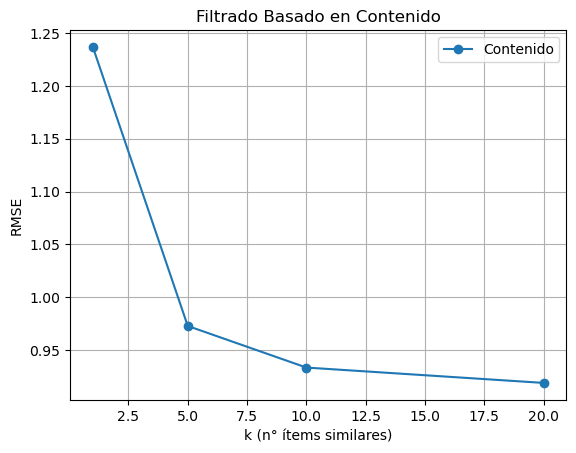

In [18]:
def evaluate_rmse_content(k):
    preds, trues = [], []

    for _, row in test_ratings.iterrows():
        pred = predict_content(row['userId'], row['movieId'], k)
        if not np.isnan(pred):
            preds.append(pred)
            trues.append(row['rating'])

    return math.sqrt(mean_squared_error(trues, preds))

ks = [1, 5, 10, 20]
rmses_content = [evaluate_rmse_content(k) for k in ks]

plt.plot(ks, rmses_content, marker='o', label="Contenido")
plt.xlabel("k (n° ítems similares)")
plt.ylabel("RMSE")
plt.title("Filtrado Basado en Contenido")
plt.grid(True)
plt.legend()
plt.show()


**Este código define una función evaluate_rmse_content(k) que evalúa la calidad de las predicciones hechas por el modelo de filtrado basado en contenido utilizando la métrica RMSE (Root Mean Squared Error). Para cada interacción en el conjunto de prueba (test_ratings), la función predice la calificación que un usuario daría a una película usando predict_content(userId, movieId, k), donde k es el número de películas similares a considerar; si la predicción es válida (no NaN), guarda tanto la predicción como la calificación real. Luego, calcula el RMSE entre las calificaciones reales y las predichas, que mide qué tan cerca están en promedio las predicciones del modelo respecto a los valores reales (un RMSE más bajo es mejor). Después, se define una lista de valores de k ([1, 5, 10, 20]) y se calcula el RMSE para cada uno usando la función evaluate_rmse_content. Finalmente, se genera una gráfica donde el eje X representa los diferentes valores de k (el número de películas similares que se usan en la predicción), el eje Y muestra el RMSE correspondiente, y se dibuja la curva para visualizar cómo cambia el error a medida que se usan más vecinos en las predicciones. Así, puedes analizar visualmente qué valor de k ofrece el mejor equilibrio entre precisión y generalización para tu sistema de recomendación basado en contenido.**

**En el gráfico anterior, pdemos observar como a medida que aumentan los k, mejora el rmse. Sin embargo en caso de tener un k excesivamente alto, podría dar lugar a subajuste y una faltabde excatitud en la predicción. Siendo opuesto cuando el k es demasiado pequeño, por ejemplo 1. En este caso, el modelo se sobreajusta a muy pocas películas similares y dar lugar a una alta variabilidad**

 # Matriz MSD 

In [48]:
user_item_matrix = train_ratings.pivot(index="userId", columns="movieId", values="rating").astype(float)
user_ids = user_item_matrix.index
user_id_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
user_matrix = user_item_matrix.values

def msd_similarity(matrix):
    n_users = matrix.shape[0]
    sim_matrix = np.zeros((n_users, n_users))

    for i in range(n_users):
        for j in range(i + 1, n_users):
            common = ~np.isnan(matrix[i]) & ~np.isnan(matrix[j])
            if np.any(common):
                diff = matrix[i][common] - matrix[j][common]
                msd = np.mean(diff ** 2)
                sim = 1 / (1 + msd)
                sim_matrix[i, j] = sim_matrix[j, i] = sim
            else:
                sim_matrix[i, j] = sim_matrix[j, i] = 0.0

    return sim_matrix

user_sim_matrix = msd_similarity(user_matrix)

**Este código crea una matriz de interacción entre usuarios y películas a partir del conjunto de entrenamiento (train_ratings), utilizando el método pivot de pandas para construir una matriz en la que las filas representan a los usuarios, las columnas a las películas, y los valores a las calificaciones que los usuarios han dado a las películas, convirtiendo los valores a tipo float. Luego, genera un diccionario que mapea cada userId a un índice único dentro de la matriz. Después, la función msd_similarity(matrix) calcula la similitud entre usuarios utilizando el Mean Squared Difference (MSD). Para cada par de usuarios, compara las calificaciones que ambos han dado a las mismas películas (comunes), calcula la diferencia al cuadrado entre sus calificaciones, y luego obtiene la media de esas diferencias al cuadrado. La similitud entre los usuarios se calcula como el inverso de 1 más el MSD, de forma que valores más bajos de MSD resultan en una mayor similitud. Si no hay películas comunes entre dos usuarios, la similitud se establece en 0. Finalmente, la función devuelve una matriz de similitudes entre todos los usuarios, user_sim_matrix, que puede ser utilizada para realizar recomendaciones basadas en la similitud entre usuarios.**

In [50]:
print(msd_similarity(user_matrix))


[[0.         0.         0.09427609 ... 0.2919708  0.42857143 0.5       ]
 [0.         0.         0.         ... 0.68965517 0.5        0.62337662]
 [0.09427609 0.         0.         ... 0.12413793 0.         0.19047619]
 ...
 [0.2919708  0.68965517 0.12413793 ... 0.         0.57142857 0.44002211]
 [0.42857143 0.5        0.         ... 0.57142857 0.         0.2745098 ]
 [0.5        0.62337662 0.19047619 ... 0.44002211 0.2745098  0.        ]]

# Matriz usuario item 

In [56]:
user_item_matrix = ratings.pivot(index="userId", columns="movieId", values="rating").astype(float)
user_item_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**El código crea una matriz de usuario-película utilizando el método pivot de pandas, transformando el DataFrame de calificaciones (ratings) en una tabla donde las filas corresponden a los usuarios (userId), las columnas a las películas (movieId), y los valores de la tabla son las calificaciones (rating) que los usuarios han dado a las películas. Luego, mediante .astype(float), asegura que todos los valores de la matriz sean de tipo float, lo cual es necesario para realizar cálculos matemáticos y de similitud en el análisis de datos. Finalmente, user_item_matrix.head() muestra las primeras 5 filas de la matriz resultante, permitiendo inspeccionar cómo se distribuyen las calificaciones entre usuarios y películas. Este tipo de matriz es fundamental en sistemas de recomendación, ya que facilita la comparación de patrones de calificación entre usuarios y películas, y es utilizada en técnicas como el filtrado colaborativo, donde la similitud entre usuarios o entre películas es calculada para generar recomendaciones personalizadas.**

In [58]:
def msd_similarity(matrix):
    users = matrix.index
    n_users = len(users)
    sim_matrix = np.zeros((n_users, n_users))

    for i in range(n_users):
        for j in range(n_users):
            if i == j:
                sim_matrix[i, j] = 1.0
            elif i < j:
                common = (~matrix.iloc[i].isna()) & (~matrix.iloc[j].isna())
                if common.sum() == 0:
                    sim = 0.0
                else:
                    diffs = matrix.iloc[i][common] - matrix.iloc[j][common]
                    sim = 1 / (1 + np.mean(diffs**2))
                sim_matrix[i, j] = sim
                sim_matrix[j, i] = sim
    return pd.DataFrame(sim_matrix, index=users, columns=users)

**La función msd_similarity toma como entrada una matriz matrix que representa las calificaciones de los usuarios para diferentes películas, donde las filas corresponden a los usuarios y las columnas a las películas. La variable users obtiene los índices (identificadores) de los usuarios y n_users almacena el número total de usuarios. Se inicializa una matriz de similitud (sim_matrix) de tamaño n_users x n_users llena de ceros. Luego, la función recorre todos los pares de usuarios (incluyendo cada usuario consigo mismo). Si los usuarios son el mismo (i == j), asigna una similitud perfecta de 1.0 en la diagonal de la matriz. Si los usuarios son diferentes (i < j), calcula la similitud de la siguiente manera: primero, identifica las películas comunes que ambos usuarios han calificado (es decir, aquellas que no son NaN para ambos usuarios). Si no tienen películas comunes, asigna una similitud de 0.0. Si tienen películas comunes, calcula la diferencia cuadrada entre sus calificaciones para esas películas, promedia las diferencias cuadradas y aplica la fórmula de similitud sim = 1 / (1 + MSD), donde el MSD es la media de las diferencias cuadradas. Después, asigna este valor de similitud tanto en la posición [i, j] como en [j, i] de la matriz de similitud, ya que la similitud es simétrica. Finalmente, la función devuelve la matriz de similitud como un DataFrame de pandas con los identificadores de usuario como índices y columnas.**

In [60]:
user_similarity = msd_similarity(user_item_matrix)
user_similarity.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.500000,0.094276,0.266272,0.481481,0.308411,0.339869,0.517241,0.833333,0.088561,...,0.721311,0.402985,0.246637,0.413793,0.263158,0.387991,0.379747,0.290133,0.473684,0.516854
2,0.500000,1.000000,0.000000,0.075472,1.000000,0.285714,0.155844,0.200000,0.000000,0.169492,...,0.473118,0.200000,0.470588,0.000000,0.000000,0.833333,0.200000,0.705882,0.500000,0.666667
3,0.094276,0.000000,1.000000,0.047059,0.047059,0.108108,0.000000,0.047059,0.000000,0.000000,...,0.057971,0.070175,0.122034,0.000000,0.800000,0.077482,0.098160,0.124138,0.000000,0.191781
4,0.266272,0.075472,0.047059,1.000000,0.230769,0.275510,0.409302,0.236842,0.200000,0.214286,...,0.163043,0.298701,0.268859,0.243243,0.390244,0.316049,0.276190,0.232704,0.214286,0.256659
5,0.481481,1.000000,0.047059,0.230769,1.000000,0.339623,0.444444,0.333333,0.000000,0.155844,...,0.444444,0.319588,0.357143,0.463415,0.306011,0.453202,0.405405,0.331492,0.625000,0.394366


**El valor 0.500000 entre el usuario 1 y el usuario 2 indica que hay una similitud moderada entre los dos en sus calificaciones.**

**El valor 0.094276 entre el usuario 1 y el usuario 3 indica que los patrones de calificación entre estos dos usuarios son bastante diferentes.**

# Predicción calificación(filtrado colaborativo)

In [63]:
def predict_collaborative(user_id, movie_id, k):
    if user_id not in user_id_to_index or movie_id not in user_item_matrix.columns:
        return np.nan

    user_idx = user_id_to_index[user_id]
    sims = user_sim_matrix[user_idx]

    # Usuarios que valoraron esta película
    rated_users = user_item_matrix[~user_item_matrix[movie_id].isna()].index
    rated_user_indices = [user_id_to_index[u] for u in rated_users if u in user_id_to_index]

    if not rated_user_indices:
        return np.nan

    sim_vals = sims[rated_user_indices]
    ratings = user_item_matrix.loc[rated_users, movie_id].values

    top_k_idx = sim_vals.argsort()[-k:]
    top_k_sims, top_k_ratings = sim_vals[top_k_idx], ratings[top_k_idx]

    return np.dot(top_k_sims, top_k_ratings) / np.sum(top_k_sims) if np.sum(top_k_sims) > 0 else np.mean(top_k_ratings)


**La función predict_collaborative realiza una predicción de la calificación que un usuario daría a una película utilizando un enfoque de filtrado colaborativo basado en la similitud entre usuarios. Primero, verifica que el user_id y movie_id sean válidos, es decir, que el usuario exista en la matriz de usuarios y que la película haya sido calificada por al menos un usuario. Luego, obtiene las similitudes entre el usuario objetivo y todos los demás usuarios, utilizando una matriz de similitudes precomputada (user_sim_matrix). A continuación, identifica los usuarios que han calificado la película y extrae tanto las similitudes de esos usuarios con el usuario objetivo como las calificaciones correspondientes para esa película. Si existen usuarios con calificaciones, la función selecciona los k usuarios más similares (basado en sus similitudes), y calcula la predicción ponderando sus calificaciones por la similitud de cada usuario, usando la fórmula de la media ponderada. Si la suma de las similitudes es cero (lo que indicaría que no hay usuarios similares), devuelve la media de las calificaciones de esos usuarios para la película. Este enfoque de predicción permite recomendar películas basadas en el gusto de usuarios similares al usuario objetivo, utilizando un método clásico de filtrado colaborativo basado en similitudes entre usuarios.**

In [71]:
print(predict_collaborative(2, 45, 5))


3.9457274826789845

In [75]:
sim_scores = user_similarity.loc[1]
print(sim_scores)

userId
1      1.000000
2      0.500000
3      0.094276
4      0.266272
5      0.481481
         ...   
606    0.387991
607    0.379747
608    0.290133
609    0.473684
610    0.516854
Name: 1, Length: 610, dtype: float64

**user_similarity es una matriz de similitud entre usuarios, donde las filas y las columnas están indexadas por los userId. La matriz contiene las similitudes entre todos los pares de usuarios.**

**user_similarity.loc[1] selecciona la fila correspondiente al userId = 1 (esto es lo que hace loc[1], donde 1 es el identificador del usuario). Esta fila contiene las similitudes entre el usuario 1 y todos los demás usuarios en la base de datos.**

**Al hacer print(sim_scores), se imprime la serie de similitudes del usuario 1 con respecto a todos los otros usuarios en el sistema.**

In [79]:
other_ratings = user_item_matrix[1]
print(other_ratings)

userId
1      4.0
2      NaN
3      NaN
4      NaN
5      4.0
      ... 
606    2.5
607    4.0
608    2.5
609    3.0
610    5.0
Name: 1, Length: 610, dtype: float64

In [81]:
sim_and_ratings = pd.concat([sim_scores, other_ratings], axis=1, keys=["sim", "rating"]).dropna()
print(sim_and_ratings)

sim  rating
userId                  
1       1.000000     4.0
5       0.481481     4.0
7       0.339869     4.5
15      0.421941     2.5
17      0.641350     4.5
...          ...     ...
606     0.387991     2.5
607     0.379747     4.0
608     0.290133     2.5
609     0.473684     3.0
610     0.516854     5.0

[215 rows x 2 columns]

# RMSE FILTRADO COLABORATIVO

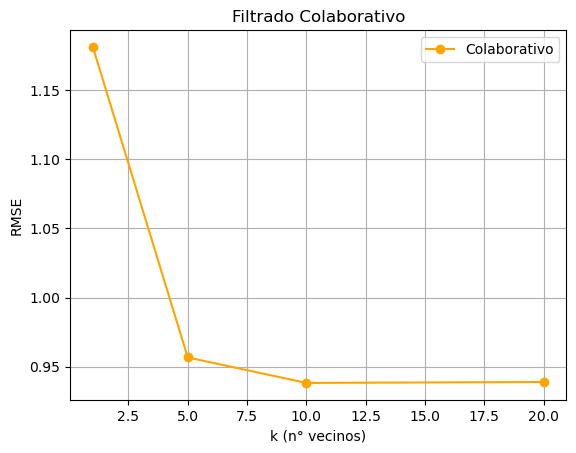

In [30]:
def evaluate_rmse_collab(k):
    preds, trues = [], []

    for _, row in test_ratings.iterrows():
        pred = predict_collaborative(row['userId'], row['movieId'], k)
        if not np.isnan(pred):
            preds.append(pred)
            trues.append(row['rating'])

    return math.sqrt(mean_squared_error(trues, preds))

rmses_collab = [evaluate_rmse_collab(k) for k in ks]

plt.plot(ks, rmses_collab, marker='o', label="Colaborativo", color="orange")
plt.xlabel("k (n° vecinos)")
plt.ylabel("RMSE")
plt.title("Filtrado Colaborativo")
plt.grid(True)
plt.legend()
plt.show()


**El código define la función evaluate_rmse_collab(k), que evalúa el desempeño de un modelo de filtrado colaborativo midiendo su precisión con el RMSE (Root Mean Squared Error), utilizando el número de vecinos más cercanos k para hacer las predicciones. Para cada valor de k, recorre el conjunto de prueba test_ratings, predice las calificaciones que un usuario daría a una película con la función predict_collaborative, y calcula el error entre las calificaciones predichas y las reales. Si la predicción es válida (no NaN), se agrega a las listas de predicciones y calificaciones reales. Después, la función calcula el RMSE usando la raíz cuadrada del error cuadrático medio. Se evalúa este RMSE para diferentes valores de k (como 1, 5, 10, 20), y los resultados se grafican, mostrando cómo cambia el RMSE según el número de vecinos considerados. El gráfico generado ayuda a visualizar el impacto de k en la precisión del modelo de filtrado colaborativo, permitiendo identificar el valor óptimo de k para minimizar el error y mejorar las predicciones.**

# COMPARACIÓN AMBOS RMSE DE LOS DOS MÉTODOS

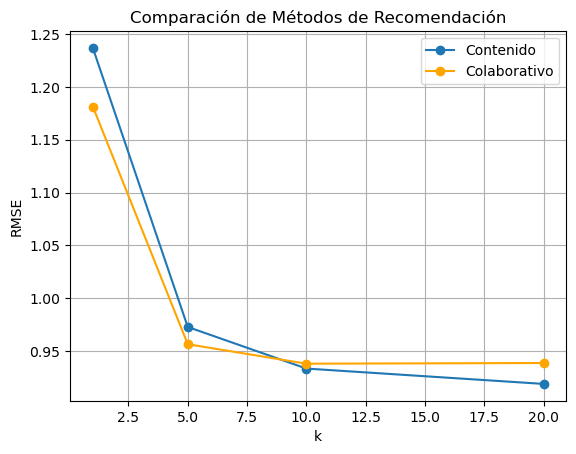

k=1: RMSE Contenido = 1.2368 | RMSE Colaborativo = 1.1814
k=5: RMSE Contenido = 0.9730 | RMSE Colaborativo = 0.9567
k=10: RMSE Contenido = 0.9336 | RMSE Colaborativo = 0.9382
k=20: RMSE Contenido = 0.9191 | RMSE Colaborativo = 0.9389


In [32]:
plt.plot(ks, rmses_content, marker='o', label="Contenido")
plt.plot(ks, rmses_collab, marker='o', label="Colaborativo", color='orange')
plt.xlabel("k")
plt.ylabel("RMSE")
plt.title("Comparación de Métodos de Recomendación")
plt.legend()
plt.grid(True)
plt.show()

for k_val, rmse_c, rmse_u in zip(ks, rmses_content, rmses_collab):
    print(f"k={k_val}: RMSE Contenido = {rmse_c:.4f} | RMSE Colaborativo = {rmse_u:.4f}")


**Cuando k = 1:El RMSE del filtrado basado en contenido (1.2368) es ligeramente mayor que el RMSE del filtrado colaborativo (1.1814). Esto sugiere que, con un solo vecino más cercano, el modelo de filtrado colaborativo está haciendo predicciones más precisas en comparación con el modelo basado en contenido.**

**Cuando k = 5:Ambos métodos muestran una mejora en sus resultados, ya que los RMSE disminuyen en comparación con el valor de k = 1. El RMSE del filtrado colaborativo (0.9567) sigue siendo más bajo que el del filtrado basado en contenido (0.9730), lo que indica que el filtrado colaborativo sigue teniendo un rendimiento ligeramente mejor con un número mayor de vecinos.**

**Cuando k = 10:A este valor de k, el RMSE del filtrado basado en contenido (0.9336) es un poco más bajo que el RMSE del filtrado colaborativo (0.9382), lo que sugiere que, en este caso, el modelo basado en contenido ha alcanzado una mayor precisión en las predicciones que el colaborativo.**

**Cuando k = 20:Los RMSE de ambos modelos se aproximan, pero el filtrado basado en contenido (0.9191) sigue siendo ligeramente mejor que el filtrado colaborativo (0.9389). Esto podría indicar que, con más vecinos, el modelo basado en contenido sigue siendo más eficiente en este conjunto de datos, o que el filtrado colaborativo no ha mejorado significativamente al aumentar el número de vecinos.**

**Filtrado colaborativo muestra un rendimiento mejor cuando k = 1 y sigue siendo competitivo hasta k = 5. Sin embargo, al aumentar k, el filtrado basado en contenido parece tener un mejor desempeño, especialmente a partir de k = 10, lo que sugiere que el modelo basado en contenido podría ser más robusto a medida que se consideran más vecinos.El rendimiento de ambos modelos depende del valor de k, y no siempre uno es claramente superior al otro en todas las configuraciones. La selección del modelo más adecuado puede depender del contexto y de la naturaleza de los datos, así como de otros factores, como la cantidad de información disponible sobre los usuarios y las películas.**

# Código extra para reforzar la coherencia del estudio 

In [94]:
# Validar proporciones de train/test
print(f"Entrenamiento: {len(train_ratings)} valoraciones ({len(train_ratings)/len(ratings)*100:.2f}%)")
print(f"Prueba: {len(test_ratings)} valoraciones ({len(test_ratings)/len(ratings)*100:.2f}%)")

# Validar que todos los usuarios de prueba están también en entrenamiento
usuarios_train = set(train_ratings['userId'])
usuarios_test = set(test_ratings['userId'])

usuarios_unicos = usuarios_test - usuarios_train
print("Usuarios en test pero no en train:", usuarios_unicos if usuarios_unicos else "Ninguno, correcto ")


Entrenamiento: 80419 valoraciones (79.75%)

Prueba: 20417 valoraciones (20.25%)

Usuarios en test pero no en train: Ninguno, correcto ✅

**Este código tiene como objetivo validar la distribución y la consistencia de los conjuntos de entrenamiento y prueba en un modelo de recomendación. Primero, calcula y muestra el número de valoraciones en los conjuntos de entrenamiento y prueba, junto con el porcentaje que representan del total de valoraciones, asegurando que la partición de los datos sea proporcional. Luego, verifica que todos los usuarios en el conjunto de prueba estén presentes en el conjunto de entrenamiento, lo cual es fundamental para que el modelo pueda hacer recomendaciones para esos usuarios basándose en sus interacciones previas. Si se encuentran usuarios en el conjunto de prueba que no están en el de entrenamiento, se mostrarán en la salida; si no, el código confirma que la partición es correcta. Esto garantiza que el proceso de evaluación del modelo no esté sesgado y que las predicciones se hagan solo para usuarios con información previa en el entrenamiento.**

In [ ]:
# Análisis EDA

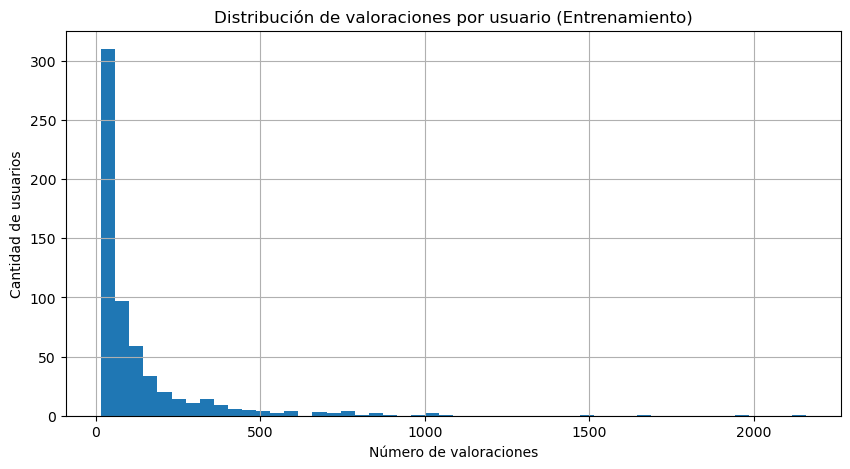

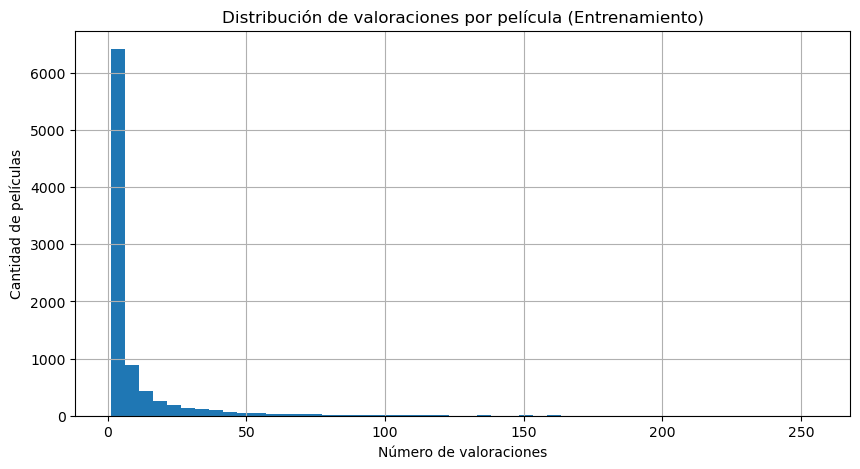

In [98]:
import matplotlib.pyplot as plt

# Distribución de valoraciones por usuario
plt.figure(figsize=(10,5))
train_ratings['userId'].value_counts().hist(bins=50)
plt.title('Distribución de valoraciones por usuario (Entrenamiento)')
plt.xlabel('Número de valoraciones')
plt.ylabel('Cantidad de usuarios')
plt.grid(True)
plt.show()

# Distribución de valoraciones por película
plt.figure(figsize=(10,5))
train_ratings['movieId'].value_counts().hist(bins=50)
plt.title('Distribución de valoraciones por película (Entrenamiento)')
plt.xlabel('Número de valoraciones')
plt.ylabel('Cantidad de películas')
plt.grid(True)
plt.show()


In [ ]:
# Medida tiempo ejecución 

In [102]:
import time
import pandas as pd

# Valores de k que quieres evaluar
k_values = [1, 5, 10, 20]

# Ejemplos de user_id y movie_id (puedes cambiar)
user_id = 1
movie_id = 1

# Listas para guardar resultados
contenido_times = []
colaborativo_times = []

# Medir tiempos para cada k
for k in k_values:
    # Tiempo para filtrado basado en contenido
    start_time = time.time()
    prediccion_contenido = predict_content(user_id, movie_id, k)
    end_time = time.time()
    contenido_times.append(end_time - start_time)
    
    # Tiempo para filtrado colaborativo
    start_time = time.time()
    prediccion_colaborativo = predict_collaborative(user_id, movie_id, k)
    end_time = time.time()
    colaborativo_times.append(end_time - start_time)

# Crear un DataFrame bonito para mostrar resultados
resultados_tiempos = pd.DataFrame({
    'k': k_values,
    'Tiempo Filtrado Contenido (s)': contenido_times,
    'Tiempo Filtrado Colaborativo (s)': colaborativo_times
})

# Mostrar la tablita
print(resultados_tiempos)


k  Tiempo Filtrado Contenido (s)  Tiempo Filtrado Colaborativo (s)
0   1                       0.011996                          0.016585
1   5                       0.003043                          0.004880
2  10                       0.003658                          0.003324
3  20                       0.002414                          0.002947

**Este código mide el tiempo de ejecución de las predicciones realizadas mediante filtrado basado en contenido y filtrado colaborativo para diferentes valores de k, que representan el número de vecinos más cercanos utilizados en el proceso de recomendación. Se define un conjunto de valores de k (1, 5, 10, 20) y para cada valor, se mide el tiempo necesario para hacer una predicción con ambas técnicas (contenido y colaborativo) usando las funciones predict_content y predict_collaborative. Los tiempos se registran en listas y luego se organizan en un DataFrame de Pandas que muestra el tiempo de ejecución de cada método para cada valor de k. Finalmente, el DataFrame se imprime, permitiendo comparar la eficiencia temporal de ambos enfoques y evaluar cómo el valor de k influye en el rendimiento de cada técnica.**

**Esto sugiere que el filtrado basado en contenido es más eficiente en términos de tiempo de ejecución para este conjunto de datos y valores de k, y que ambos métodos se vuelven más rápidos con valores de k más grandes.**